In [3]:
import pandas as pd
import kagglehub
import os

# 1. Descarga automática del dataset
# Esto descarga los archivos en una carpeta de cache de kagglehub
path = kagglehub.dataset_download("melissamonfared/spotify-tracks-attributes-and-popularity")

# 2. Localizamos el CSV
csv_path = os.path.join(path, "dataset.csv")

# 3. Carga el DataFrame
df = pd.read_csv(csv_path)

# 4. Chequeo rápido de integridad
print("--- FÁBRICA DE MANZANAS INICIADA ---")
print(f"Número de canciones (filas): {df.shape[0]}")
print(f"Número de características (columnas): {df.shape[1]}")

# 5. Buscamos 'agujeros' (nulos)
nulls = df.isnull().sum()
print("\n--- REPORTE DE CALIDAD DE DATOS ---")
if nulls.sum() == 0:
    print("¡Datos perfectos! No hay nulos.")
else:
    print("Columnas con datos faltantes:")
    print(nulls[nulls > 0])

--- FÁBRICA DE MANZANAS INICIADA ---
Número de canciones (filas): 114000
Número de características (columnas): 21

--- REPORTE DE CALIDAD DE DATOS ---
Columnas con datos faltantes:
artists       1
album_name    1
track_name    1
dtype: int64


In [4]:
# 1. Borramos las filas con nulos
df = df.dropna()

# 2. Verificamos el nuevo tamaño
print("--- LIMPIEZA COMPLETADA ---")
print(f"Nuevo shape tras limpieza: {df.shape}")

# 3. Doble chequeo de nulos (debería dar 0)
print("\nNulos restantes:", df.isnull().sum().sum())

--- LIMPIEZA COMPLETADA ---
Nuevo shape tras limpieza: (113999, 21)

Nulos restantes: 0


Distribución de 'explicit':
explicit
False    104252
True       9747
Name: count, dtype: int64


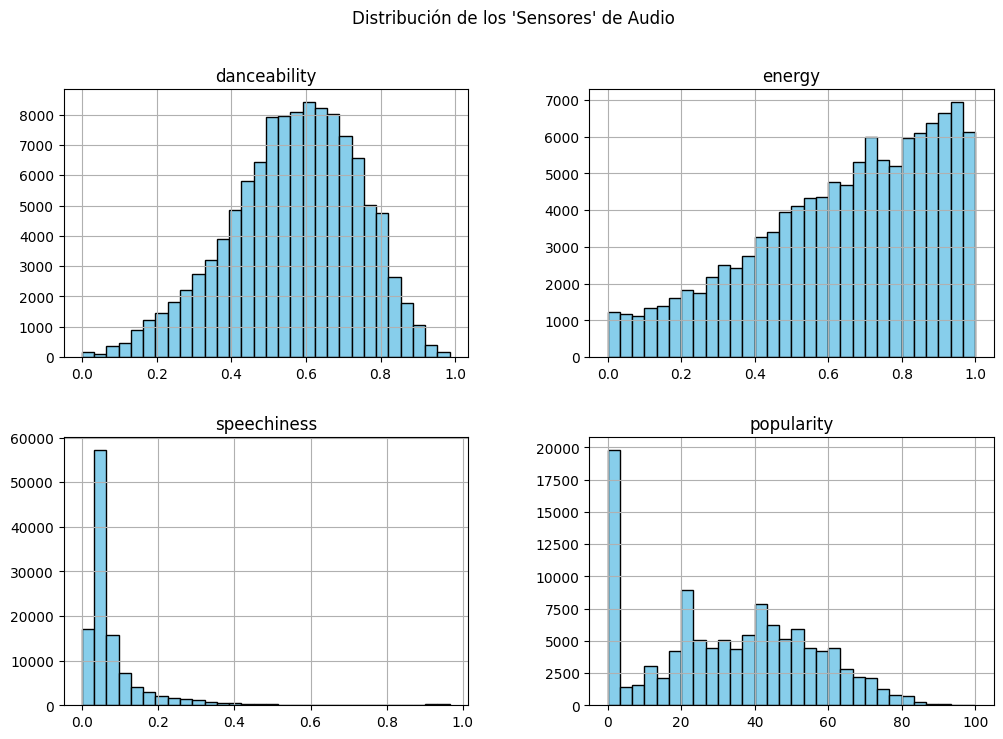

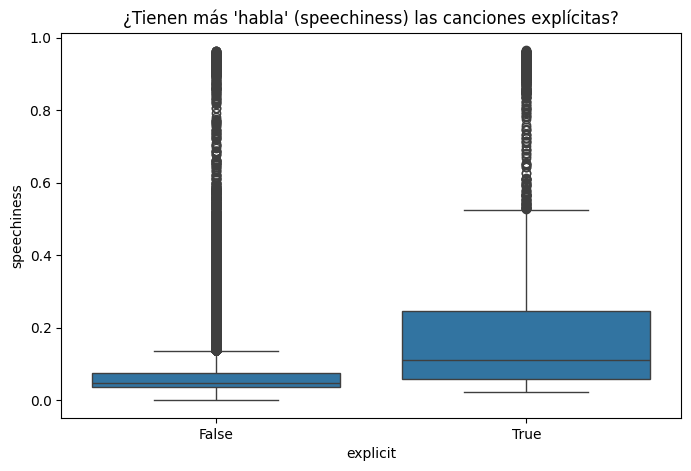

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. ¿Cuántas canciones son explícitas? (Desbalance)
print("Distribución de 'explicit':")
print(df['explicit'].value_counts())

# 2. Histogramas de las características numéricas
# Vamos a ver 4 de ellas para no saturar
features_num = ['danceability', 'energy', 'speechiness', 'popularity']
df[features_num].hist(bins=30, figsize=(12, 8), color='skyblue', edgecolor='black')
plt.suptitle("Distribución de los 'Sensores' de Audio")
plt.show()

# 3. Comparación (Boxplot): ¿Varía el 'speechiness' según si es explicit o no?
plt.figure(figsize=(8, 5))
sns.boxplot(x='explicit', y='speechiness', data=df)
plt.title("¿Tienen más 'habla' (speechiness) las canciones explícitas?")
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Definimos las 11 características (sensores) y el objetivo (target)
feature_cols = ['popularity', 'duration_ms', 'danceability', 'energy', 'loudness', 
                'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

X = df[feature_cols]
y = df['explicit'].astype(int)  # Convertimos True/False a 1/0

# 2. Dividimos 80% para estudiar y 20% para el examen
# Stratify=y asegura que el desbalance se mantenga igual en ambos grupos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Escalamos los datos (Estandarización)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("--- PREPARACIÓN COMPLETADA ---")
print(f"Entrenamiento: {X_train_sc.shape[0]} canciones")
print(f"Examen final: {X_test_sc.shape[0]} canciones")

--- PREPARACIÓN COMPLETADA ---
Entrenamiento: 91199 canciones
Examen final: 22800 canciones


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Creamos y entrenamos la "balanza"
modelo_bin = LogisticRegression(max_iter=1000, random_state=42)
modelo_bin.fit(X_train_sc, y_train)

# 2. Hacemos que la máquina haga el examen
y_pred_bin = modelo_bin.predict(X_test_sc)

# 3. Miramos los resultados
print("--- MODELO BINARIO ENTRENADO ---")
print(f"Accuracy (Precisión Global): {accuracy_score(y_test, y_pred_bin):.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_bin))

--- MODELO BINARIO ENTRENADO ---
Accuracy (Precisión Global): 0.9143

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95     20851
           1       0.49      0.09      0.16      1949

    accuracy                           0.91     22800
   macro avg       0.71      0.54      0.56     22800
weighted avg       0.88      0.91      0.89     22800



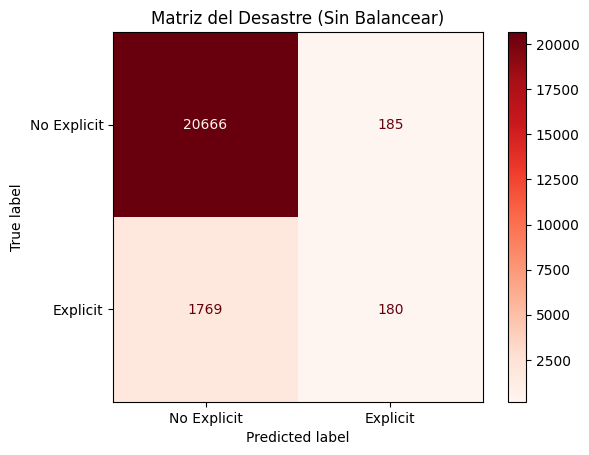


--- MODELO BALANCEADO (CON PESOS) ---
              precision    recall  f1-score   support

           0       0.97      0.74      0.84     20851
           1       0.21      0.72      0.32      1949

    accuracy                           0.74     22800
   macro avg       0.59      0.73      0.58     22800
weighted avg       0.90      0.74      0.79     22800



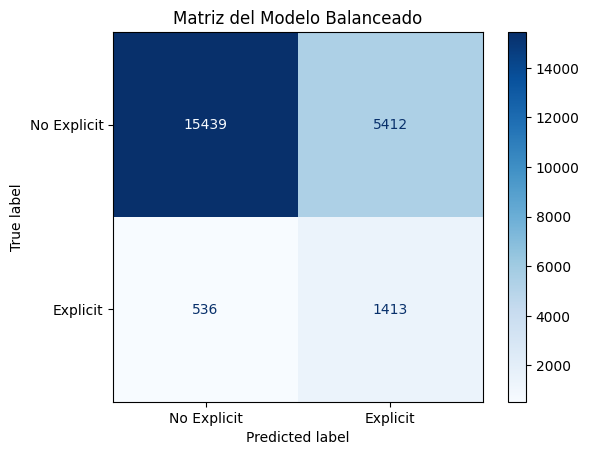

In [10]:
# 1. Visualizamos el desastre del modelo anterior
cm = confusion_matrix(y_test, y_pred_bin)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Explicit', 'Explicit'])
disp.plot(cmap='Reds')
plt.title("Matriz del Desastre (Sin Balancear)")
plt.show()

# 2. ENTRENAMOS EL MODELO JUSTO (Balanced)
modelo_bal = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
modelo_bal.fit(X_train_sc, y_train)
y_pred_bal = modelo_bal.predict(X_test_sc)

# 3. Reporte del nuevo modelo
print("\n--- MODELO BALANCEADO (CON PESOS) ---")
print(classification_report(y_test, y_pred_bal))

# 4. Nueva Matriz
cm_bal = confusion_matrix(y_test, y_pred_bal)
disp_bal = ConfusionMatrixDisplay(confusion_matrix=cm_bal, display_labels=['No Explicit', 'Explicit'])
disp_bal.plot(cmap='Blues')
plt.title("Matriz del Modelo Balanceado")
plt.show()

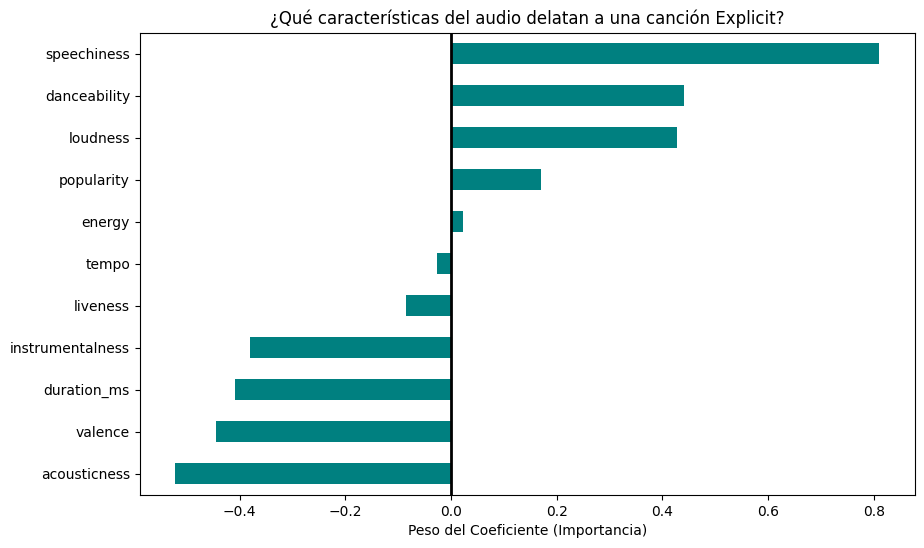

Coeficientes ordenados:
acousticness       -0.522380
valence            -0.445413
duration_ms        -0.408657
instrumentalness   -0.379699
liveness           -0.084494
tempo              -0.027481
energy              0.023505
popularity          0.170076
loudness            0.427555
danceability        0.441663
speechiness         0.810695
dtype: float64


In [11]:
# 1. Extraemos los coeficientes (los 'pesos' que la máquina dio a cada sensor)
import pandas as pd

coefs = pd.Series(modelo_bal.coef_[0], index=feature_cols).sort_values()

# 2. Graficamos
plt.figure(figsize=(10, 6))
coefs.plot(kind='barh', color='teal')
plt.axvline(0, color='black', lw=2) # Una línea en el cero para ver la frontera
plt.title("¿Qué características del audio delatan a una canción Explicit?")
plt.xlabel("Peso del Coeficiente (Importancia)")
plt.show()

# 3. Imprimimos los valores para ver el detalle
print("Coeficientes ordenados:")
print(coefs)

In [12]:
# 1. Filtramos el dataset para quedarnos solo con 4 géneros
generos_elegidos = ['pop', 'rock', 'hip-hop', 'classical']
df_multi = df[df['track_genre'].isin(generos_elegidos)].copy()

# 2. Definimos X (las 11 features) e y (el género musical)
X_multi = df_multi[feature_cols]
y_multi = df_multi['track_genre']

# 3. Verificamos que estén balanceados
print("Distribución por género:")
print(y_multi.value_counts())

# 4. Hacemos el Split y un NUEVO Escalado
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42, stratify=y_multi
)

scaler_multi = StandardScaler()
X_train_m_sc = scaler_multi.fit_transform(X_train_m)
X_test_m_sc = scaler_multi.transform(X_test_m)

print("\n--- PREPARACIÓN MULTICLASE COMPLETADA ---")
print(f"Total canciones para entrenar: {X_train_m_sc.shape[0]}")

Distribución por género:
track_genre
classical    1000
hip-hop      1000
pop          1000
rock         1000
Name: count, dtype: int64

--- PREPARACIÓN MULTICLASE COMPLETADA ---
Total canciones para entrenar: 3200
